## Protein Language Model Embeddings with ESM2

In the next section, the notebook moves from manual sequence encoding to learned protein representations using ESM2.  
Unlike one hot encoding, ESM2 embeddings capture contextual and biochemical relationships between amino acids.

## Imports

The following libraries are used for tensor operations and visualization.

In [ ]:
import torch                      # PyTorch tensors
import torch.nn.functional as F   # Neural network functions (e.g., softmax, one-hot)

import seaborn as sns             # Statistical visualizations
import matplotlib.pyplot as plt   # Plotting

from transformers import AutoTokenizer, EsmModel # Hugging Face classes for tokenizer and pretrained ESM2 model
from transformers import EsmForMaskedLM          # ESM2 model for masked amino acid prediction

from sklearn.manifold import TSNE  # t-SNE dimensionality reduction
import umap.umap_ as umap          # UMAP dimensionality reduction

from adjustText import adjust_text  # Reduce overlapping text labels in plots
import pandas as pd                 # DataFrames for structured data handling

import logging  # Control Hugging Face warning messages
import warnings  # Control Python warning messages

In [4]:
torch.set_printoptions(
    precision=1,                  # Show 1 decimal place
    linewidth=200,                # Wider display before wrapping lines
    sci_mode=False                # Disable scientific notation
)

# Hide Transformers model loading warnings
logging.getLogger("transformers.modeling_utils").setLevel(logging.ERROR)


# Hide specific UMAP warning related to reproducibility settings
warnings.filterwarnings(
    "ignore",
    message="n_jobs value 1 overridden to 1 by setting random_state"
)

## Human Preproinsulin Sequence

Human preproinsulin is the precursor form of insulin.  
Its amino acid sequence is represented here using the standard single-letter amino acid code.

In [5]:
# Human preproinsulin amino acid sequence (single-letter code)
# This is the full precursor protein synthesized from the INS gene.
# It includes:
# 1. Signal peptide
# 2. B chain
# 3. C-peptide
# 4. A chain

human_preproinsulin = (
    "MALWMRLLPLLALLALWGPDPAAA"
    "FVNQHLCGSHLVEALYLVCGERGFFYTPKT"
    "RREAEDLQVGQVELGGGPGAGSLQPLALEGSLQKR"
    "GIVEQCCTSICSLYQLENYCN"
)

# Count total number of amino acids in the precursor protein
sequence_length = len(human_preproinsulin)

# Display result
print(f"Human preproinsulin length: {sequence_length} amino acids")

Human preproinsulin length: 110 amino acids


## Standard Amino Acid Alphabet

The standard protein alphabet contains 20 amino acids, each represented by a single-letter code.

In [6]:
# Standard 20 amino acids (single-letter codes)
amino_acids = [
    "R",  # Arginine
    "H",  # Histidine
    "K",  # Lysine
    "D",  # Aspartic acid
    "E",  # Glutamic acid
    "S",  # Serine
    "T",  # Threonine
    "N",  # Asparagine
    "Q",  # Glutamine
    "G",  # Glycine
    "P",  # Proline
    "C",  # Cysteine
    "A",  # Alanine
    "V",  # Valine
    "I",  # Isoleucine
    "L",  # Leucine
    "M",  # Methionine
    "F",  # Phenylalanine
    "Y",  # Tyrosine
    "W",  # Tryptophan
]

print(f"Standard amino acid count: {len(amino_acids)} / 20")

Standard amino acid count: 20 / 20


## Amino Acid to Index Mapping

To prepare protein sequences for machine learning, each amino acid is mapped to a numeric index.

In [7]:
# Create mapping: amino acid letter -> numeric index
amino_acid_to_index = {
    aa: idx
    for idx, aa in enumerate(amino_acids)
}

print("Amino acid to index mapping:")
print(amino_acid_to_index)

Amino acid to index mapping:
{'R': 0, 'H': 1, 'K': 2, 'D': 3, 'E': 4, 'S': 5, 'T': 6, 'N': 7, 'Q': 8, 'G': 9, 'P': 10, 'C': 11, 'A': 12, 'V': 13, 'I': 14, 'L': 15, 'M': 16, 'F': 17, 'Y': 18, 'W': 19}


## Toy Protein Example

Before encoding the full insulin precursor, a short toy protein sequence is used to demonstrate the workflow.

In [8]:
# Example toy protein sequence
toy_protein = "MARTKQLEGV"

# Convert amino acid chain to indices
toy_protein_indices = [ amino_acid_to_index[aa] for aa in toy_protein ]

print(f"Protein sequence: {toy_protein}")
print(f"Sequence length: {len(toy_protein)}")
print(f"Encoded indices: {toy_protein_indices}")

Protein sequence: MARTKQLEGV
Sequence length: 10
Encoded indices: [16, 12, 0, 6, 2, 8, 15, 4, 9, 13]


## One-Hot Encoding

Each amino acid index is transformed into a one-hot vector of length 20.  
This creates a matrix with one row per sequence position and one column per amino acid type.

In [9]:
# One-hot encode
toy_protein_one_hot = F.one_hot(
    torch.tensor(toy_protein_indices),
    num_classes=20
).float()

print(toy_protein_one_hot)
print(toy_protein_one_hot.shape)

tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
        [0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.]])
torch.Size([10, 20])


## Heatmap Visualization

The one-hot encoded toy protein is visualized as a heatmap.  
Rows represent sequence positions, and columns represent amino acid categories.

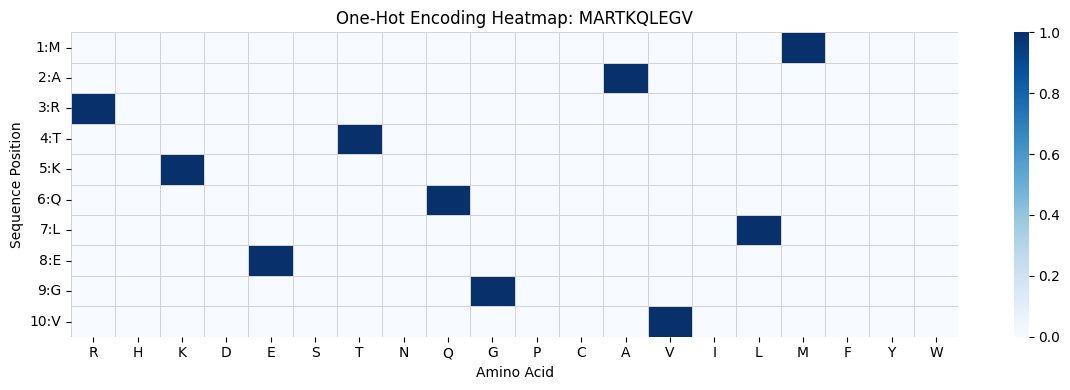

In [10]:
# Convert PyTorch tensor to NumPy for Seaborn / Matplotlib
data = toy_protein_one_hot.numpy()

# Create figure
plt.figure(figsize=(12, 4))

# Plot one-hot encoded sequence as heatmap
sns.heatmap(
    data,
    cmap="Blues",
    cbar=True,
    linewidths=0.5,
    linecolor="lightgray"
)

# Titles and axis labels
plt.title(f"One-Hot Encoding Heatmap: {toy_protein}")
plt.xlabel("Amino Acid")
plt.ylabel("Sequence Position")

# Column labels = 20 amino acid letters
plt.xticks(
    ticks=[i + 0.5 for i in range(len(amino_acids))],
    labels=amino_acids,
    rotation=0
)

# Row labels = sequence position + amino acid letter
plt.yticks(
    ticks=[i + 0.5 for i in range(len(toy_protein))],
    labels=[f"{i+1}:{aa}" for i, aa in enumerate(toy_protein)],
    rotation=0
)

# Improve spacing and show plot
plt.tight_layout()
plt.show()

## Protein Language Model Embeddings with ESM2

In the next section, the notebook moves from manual sequence encoding to learned protein representations using ESM2.  
Unlike one hot encoding, ESM2 embeddings capture contextual and biochemical relationships between amino acids.

In [11]:
# Pretrained ESM2 checkpoint (650M parameters, 33 layers)
model_checkpoint = "facebook/esm2_t33_650M_UR50D"

In [12]:
# Load tokenizer for converting protein sequences into model tokens
tokenizer = AutoTokenizer.from_pretrained(
    model_checkpoint,
    clean_up_tokenization_spaces=False  # Keep raw token spacing unchanged
)

In [13]:
# Load pretrained ESM2 model for protein embeddings
model = EsmModel.from_pretrained(model_checkpoint)

In [14]:
vocab_to_index = tokenizer.get_vocab() # Get tokenizer vocabulary mapping: token -> numeric index

print(vocab_to_index)
print(f"Vocabulary length: {len(vocab_to_index)}")

{'<cls>': 0, '<pad>': 1, '<eos>': 2, '<unk>': 3, 'L': 4, 'A': 5, 'G': 6, 'V': 7, 'S': 8, 'E': 9, 'R': 10, 'T': 11, 'I': 12, 'D': 13, 'P': 14, 'K': 15, 'Q': 16, 'N': 17, 'F': 18, 'Y': 19, 'M': 20, 'H': 21, 'W': 22, 'C': 23, 'X': 24, 'B': 25, 'U': 26, 'Z': 27, 'O': 28, '.': 29, '-': 30, '<null_1>': 31, '<mask>': 32}
Vocabulary length: 33


In [15]:
# Tokenize protein sequence and return PyTorch tensor of token IDs
tokenized_toy_protein = tokenizer(
    toy_protein,
    return_tensors="pt"
)["input_ids"]

print(tokenized_toy_protein)

tensor([[ 0, 20,  5, 10, 11, 15, 16,  4,  9,  6,  7,  2]])


## t-SNE and UMAP Visualization of ESM2 Token Embeddings

This section reduces high-dimensional ESM2 token embeddings into two dimensions using t-SNE and UMAP. These visualizations help inspect how amino acid token embeddings are organized in the pretrained model space.

In [24]:
# Convert dictionary into ordered lists
vocab_tokens = list(vocab_to_index.keys())      # Token names
vocab_token_ids = list(vocab_to_index.values()) # Numeric token IDs

print(vocab_tokens)
print(vocab_token_ids)

['<cls>', '<pad>', '<eos>', '<unk>', 'L', 'A', 'G', 'V', 'S', 'E', 'R', 'T', 'I', 'D', 'P', 'K', 'Q', 'N', 'F', 'Y', 'M', 'H', 'W', 'C', 'X', 'B', 'U', 'Z', 'O', '.', '-', '<null_1>', '<mask>']
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32]


In [25]:
# Get ESM2 token embedding matrix for visualization
vocab_token_embeddings = (
    model.get_input_embeddings()
    .weight
    .detach()
    .cpu()
    .numpy()
)

# Display shape: (vocab_size, embedding_dim)
print(vocab_token_embeddings.shape)

(33, 1280)


### t-SNE Projection

In [ ]:
tsne = TSNE(
    n_components=2,
    perplexity=10,
    random_state=2026,
    init="random",
    learning_rate="auto"
)

tsne_points = tsne.fit_transform(vocab_token_embeddings)

print(tsne_points.shape)

(33, 2)


In [49]:
# Create DataFrame with t-SNE coordinates and token labels
embeddings_tsne_df = pd.DataFrame({
    "first_dim": tsne_points[:, 0],
    "second_dim": tsne_points[:, 1],
    "token": vocab_tokens
})

embeddings_tsne_df.head()

,first_dim,second_dim,token
0,61.190643,15.805303,<cls>
1,66.474831,83.448280,<pad>
2,50.041027,0.950322,<eos>
3,51.469322,88.123177,<unk>
4,-47.711643,16.194822,L


In [50]:
# Token categories for coloring
token_annotation = {
    "hydrophobic": ["A", "F", "I", "L", "M", "V", "W", "Y"],
    "polar uncharged": ["N", "Q", "S", "T"],
    "negatively charged": ["D", "E"],
    "positively charged": ["H", "K", "R"],
    "special amino acid": ["B", "C", "G", "O", "P", "U", "X", "Z"],
    "special token": [
        "-", ".", "<cls>", "<eos>", "<mask>",
        "<null_1>", "<pad>", "<unk>"
    ],
}

In [51]:
# Reverse mapping: token -> category label
token_to_label = {
    token: label
    for label, tokens in token_annotation.items()
    for token in tokens
}

print(token_to_label)

{'A': 'hydrophobic', 'F': 'hydrophobic', 'I': 'hydrophobic', 'L': 'hydrophobic', 'M': 'hydrophobic', 'V': 'hydrophobic', 'W': 'hydrophobic', 'Y': 'hydrophobic', 'N': 'polar uncharged', 'Q': 'polar uncharged', 'S': 'polar uncharged', 'T': 'polar uncharged', 'D': 'negatively charged', 'E': 'negatively charged', 'H': 'positively charged', 'K': 'positively charged', 'R': 'positively charged', 'B': 'special amino acid', 'C': 'special amino acid', 'G': 'special amino acid', 'O': 'special amino acid', 'P': 'special amino acid', 'U': 'special amino acid', 'X': 'special amino acid', 'Z': 'special amino acid', '-': 'special token', '.': 'special token', '<cls>': 'special token', '<eos>': 'special token', '<mask>': 'special token', '<null_1>': 'special token', '<pad>': 'special token', '<unk>': 'special token'}


In [52]:
# Add category label to each token
embeddings_tsne_df["label"] = embeddings_tsne_df["token"].map(token_to_label)
embeddings_tsne_df.head()

,first_dim,second_dim,token,label
0,61.190643,15.805303,<cls>,special token
1,66.474831,83.448280,<pad>,special token
2,50.041027,0.950322,<eos>,special token
3,51.469322,88.123177,<unk>,special token
4,-47.711643,16.194822,L,hydrophobic


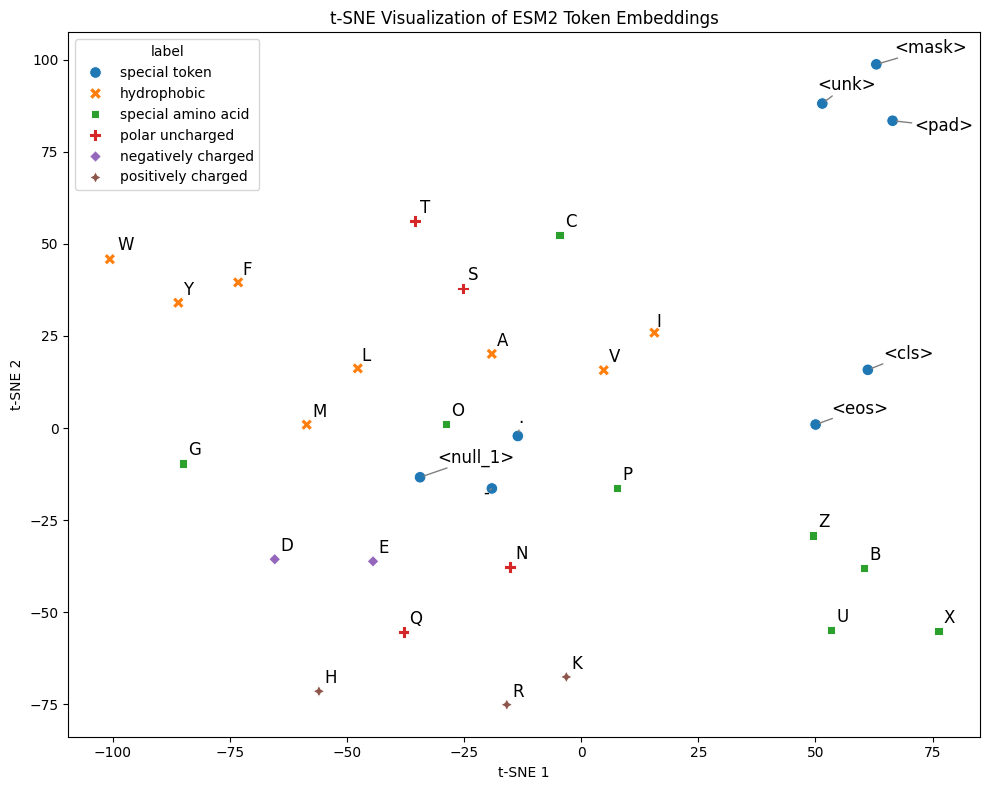

In [53]:
plt.figure(figsize=(10, 8))

ax = sns.scatterplot(
    data=embeddings_tsne_df,
    x="first_dim",
    y="second_dim",
    hue="label",
    style="label",
    s=70
)

ax.set_title("t-SNE Visualization of ESM2 Token Embeddings")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")

# Add token text labels
texts = [
    ax.text(row["first_dim"], row["second_dim"], row["token"], fontsize=12)
    for _, row in embeddings_tsne_df.iterrows()
]

# Automatically reduce label overlap
adjust_text(
    texts,
    expand=(1.5, 1.5),
    arrowprops=dict(arrowstyle="->", color="grey")
)

plt.tight_layout()
plt.show()

### UMAP Projection

In [ ]:
# UMAP projection with fixed seed for reproducibility
umap_model = umap.UMAP(
    n_components=2,
    n_neighbors=10,
    min_dist=0.1,
    random_state=2026
)
umap_points = umap_model.fit_transform(vocab_token_embeddings)

print(umap_points.shape)

(33, 2)


In [55]:
# Create DataFrame with UMAP coordinates and token labels
embeddings_umap_df = pd.DataFrame({
    "first_dim": umap_points[:, 0],
    "second_dim": umap_points[:, 1],
    "token": vocab_tokens
})

embeddings_umap_df.head()

,first_dim,second_dim,token
0,14.235841,-9.544838,<cls>
1,12.807253,-9.598642,<pad>
2,13.974073,-9.631557,<eos>
3,12.491320,-9.984787,<unk>
4,14.489890,-10.503943,L


In [56]:
# Add category label to each token
embeddings_umap_df["label"] = embeddings_umap_df["token"].map(token_to_label)
embeddings_umap_df.head()

,first_dim,second_dim,token,label
0,14.235841,-9.544838,<cls>,special token
1,12.807253,-9.598642,<pad>,special token
2,13.974073,-9.631557,<eos>,special token
3,12.491320,-9.984787,<unk>,special token
4,14.489890,-10.503943,L,hydrophobic


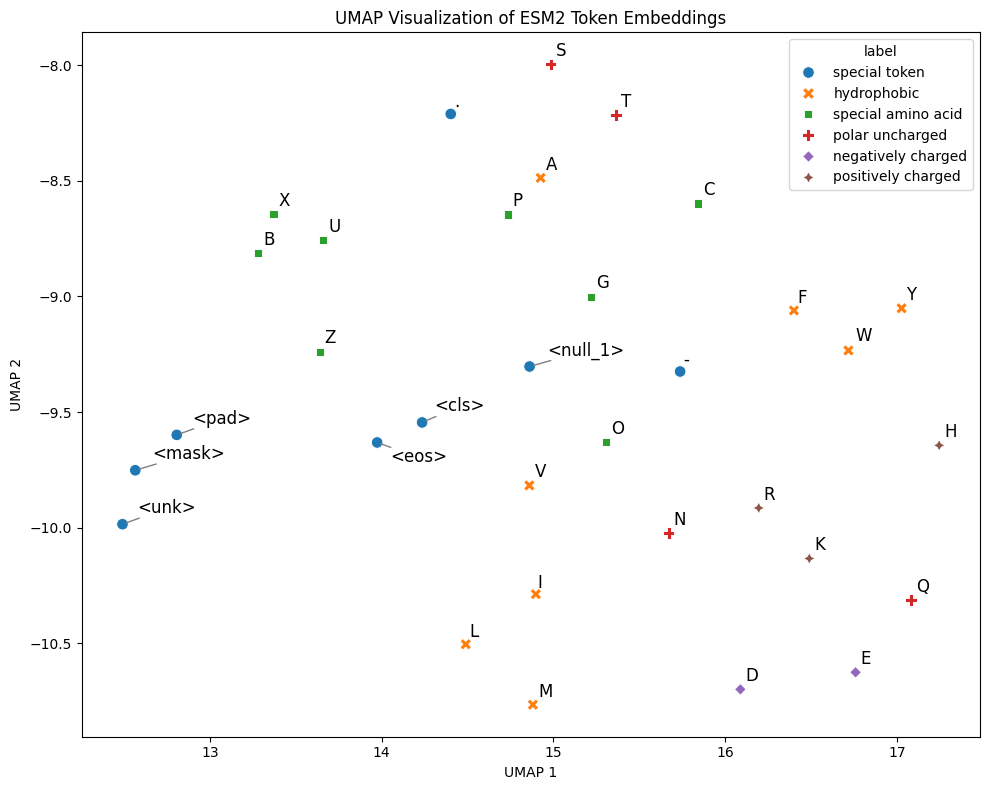

In [61]:
plt.figure(figsize=(10, 8))

ax = sns.scatterplot(
    data=embeddings_umap_df,
    x="first_dim",
    y="second_dim",
    hue="label",
    style="label",
    s=70
)

ax.set_title("UMAP Visualization of ESM2 Token Embeddings")
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")

# Add token text labels
texts = [
    ax.text(row["first_dim"], row["second_dim"], row["token"], fontsize=12)
    for _, row in embeddings_umap_df.iterrows()
]

# Automatically reduce label overlap
adjust_text(
    texts,
    expand=(1.5, 1.5),
    arrowprops=dict(arrowstyle="->", color="grey")
)

plt.tight_layout()
plt.show()

### The ESM2 Protein Language Model Masking

In [62]:
# Human preproinsulin amino acid sequence (110 aa precursor protein encoded by INS gene)
# Includes signal peptide, B chain, C-peptide, and A chain of mature insulin
insulin_sequence = (
    "MALWMRLLPLLALLALWGPDPAAAFVNQHLCGSHLVEALYLVCGERGFFYTPKTRREAEDLQVGQVELGG"
    "GPGAGSLQPLALEGSLQKRGIVEQCCTSICSLYQLENYCN"
)

In [63]:
masked_insulin_sequence = (
  # Mask the `L` amino acid in the 29th position (0-based indexing):
  #       ...LALLALWGPDPAAAFVNQH  L   CGSHLVEALYLVCGERGFF...
  "MALWMRLLPLLALLALWGPDPAAAFVNQH<mask>CGSHLVEALYLVCGERGFFYTPKTRREAEDLQVGQVELGG"
  "GPGAGSLQPLALEGSLQKRGIVEQCCTSICSLYQLENYCN"
)

In [64]:
# Tokenize the masked insulin sequence.
masked_inputs = tokenizer(masked_insulin_sequence)["input_ids"]
print(masked_inputs)

[0, 20, 5, 4, 22, 20, 10, 4, 4, 14, 4, 4, 5, 4, 4, 5, 4, 22, 6, 14, 13, 14, 5, 5, 5, 18, 7, 17, 16, 21, 32, 23, 6, 8, 21, 4, 7, 9, 5, 4, 19, 4, 7, 23, 6, 9, 10, 6, 18, 18, 19, 11, 14, 15, 11, 10, 10, 9, 5, 9, 13, 4, 16, 7, 6, 16, 7, 9, 4, 6, 6, 6, 14, 6, 5, 6, 8, 4, 16, 14, 4, 5, 4, 9, 6, 8, 4, 16, 15, 10, 6, 12, 7, 9, 16, 23, 23, 11, 8, 12, 23, 8, 4, 19, 16, 4, 9, 17, 19, 23, 17, 2]


In [65]:
# Check that we indeed have a <mask> token in the place that we expect it. Note
# that the tokenizer adds a <cls> token to the start of the sequence, so we in
# fact expect the <mask> token at position 30 (not 29).
assert masked_inputs[30] == vocab_to_index["<mask>"]

### Protein Sequence Masked Token Inference Using ESM2

In [67]:
model_checkpoint = "facebook/esm2_t30_150M_UR50D"          # Pretrained ESM2 checkpoint

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(  # Tokenizer for protein sequences
    model_checkpoint,
    clean_up_tokenization_spaces=False      # Keep raw token spacing unchanged) # Tokenizer for protein sequences
)

In [70]:
masked_lm_model = EsmForMaskedLM.from_pretrained(model_checkpoint)  # ESM2 masked language model

config.json:   0%|          | 0.00/779 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/595M [00:00<?, ?B/s]

In [ ]:
# Run masked insulin sequence through ESM2 and get model outputs
model_outputs = masked_lm_model(
    **tokenizer(text=masked_insulin_sequence, return_tensors="pt")
)

In [75]:
model_preds = model_outputs.logits  # Predicted logits for each token position

print(model_preds)
print(model_preds.shape)

tensor([[[ 18.3,  -4.7,   1.6,  ..., -15.4, -17.0,  -4.6],
         [ -3.1,  -7.0,  -3.9,  ..., -14.1, -15.4,  -7.0],
         [-10.7, -15.5, -10.3,  ..., -15.5, -15.3, -15.5],
         ...,
         [ -7.6,  -7.7,  -7.4,  ..., -15.3, -15.3,  -7.7],
         [-11.4, -17.8, -11.8,  ..., -16.9, -16.1, -17.8],
         [ -3.9,  -7.4,  18.2,  ..., -14.8, -15.4,  -7.4]]], grad_fn=<AddBackward0>)
torch.Size([1, 112, 33])


In [79]:
# Select logits at the <mask> position
mask_preds = model_preds[0, 30]

print(mask_preds)
print(mask_preds.shape)

tensor([-11.3, -19.6, -14.1, -19.6,   6.0,  -0.9,  -3.4,   1.0,  -1.5,  -4.4,  -1.0,  -1.2,   0.8,  -5.0,  -1.3,  -3.1,  -1.5,  -3.2,   2.3,   0.8,   1.0,  -0.8,  -2.1,  -2.6,  -5.5, -13.0, -12.7,
        -13.2, -15.6, -15.5, -15.1, -16.0, -19.7], grad_fn=<SelectBackward0>)
torch.Size([33])


In [ ]:





# Apply softmax to convert the model's predicted logits to probabilities.
mask_probs = jax.nn.softmax(mask_preds)

# Visualize the predicted probability of each token.
letters = list(vocab_to_index.keys())
fig, ax = plt.subplots(figsize=(6, 4))
plt.bar(letters, mask_probs, color="grey")
plt.xticks(rotation=90)
plt.title("Model Probabilities for the Masked Amino Acid.");